# Phase-2 Model Robustness — Comparison Notebook

Loads evaluation outputs from `results/` and `experiments/` and renders
all comparison tables, heatmaps, and degradation curves inline.

**Run order:**
1. Run all cells in sequence.
2. Results must already exist (`python scripts/evaluate.py -m all`).
3. For plots, also run with `--plots` flag.

In [1]:
import sys
import os
from pathlib import Path

# Resolve project root (works whether notebook is run from notebook/ or root)
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebook' else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, Image as IPImage

print(f'Project root : {PROJECT_ROOT}')
print(f'Working dir  : {os.getcwd()}')

Project root : e:\ScaleVision
Working dir  : e:\ScaleVision


## 1. Load Results

In [2]:
RAW_CSV     = PROJECT_ROOT / 'results' / 'raw_eval.csv'
RANKING_CSV = PROJECT_ROOT / 'results' / 'robustness_ranking.csv'

if not RAW_CSV.exists():
    raise FileNotFoundError(
        f'{RAW_CSV} not found.\n'
        'Run: python scripts/evaluate.py -m all'
    )

df = pd.read_csv(RAW_CSV)
print(f'raw_eval.csv  : {len(df)} rows, {df["model_id"].nunique()} models')
print(f'Columns       : {list(df.columns)}')
display(df.head(10))

raw_eval.csv  : 222 rows, 6 models
Columns       : ['model_id', 'condition_id', 'label', 'family', 'sub_aug', 'intensity_level', 'seed', 'row_idx', 'col_idx', 'map50', 'map50_95', 'precision', 'recall', 'delta_map50']


,model_id,condition_id,label,family,sub_aug,intensity_level,seed,row_idx,col_idx,map50,map50_95,precision,recall,delta_map50
0,M0,0,Clean Baseline,clean,-,-,42,0,0,0.826719,0.584761,0.923189,0.750966,0.000000
1,M0,1,Perspective Shift / Mild / seed=42,geometric,Perspective Shift,Mild,42,0,0,0.196961,0.063578,0.380910,0.298564,-0.629759
2,M0,2,Perspective Shift / Mild / seed=137,geometric,Perspective Shift,Mild,137,0,1,0.237847,0.079786,0.412143,0.331060,-0.588873
3,M0,3,Perspective Shift / Mild / seed=256,geometric,Perspective Shift,Mild,256,0,2,0.234755,0.074801,0.402286,0.345018,-0.591965
4,M0,4,Affine Transform / Moderate / seed=42,geometric,Affine Transform,Moderate,42,1,0,0.044063,0.011482,0.141798,0.112471,-0.782656
5,M0,5,Affine Transform / Moderate / seed=137,geometric,Affine Transform,Moderate,137,1,1,0.037987,0.008650,0.131376,0.099380,-0.788732
6,M0,6,Affine Transform / Moderate / seed=256,geometric,Affine Transform,Moderate,256,1,2,0.039419,0.011641,0.128795,0.100086,-0.787300
7,M0,7,Horizontal Flip / Strong / seed=42,geometric,Horizontal Flip,Strong,42,2,0,0.005975,0.001939,0.046716,0.031485,-0.820744
8,M0,8,Horizontal Flip / Strong / seed=137,geometric,Horizontal Flip,Strong,137,2,1,0.005975,0.001939,0.046716,0.031485,-0.820744
9,M0,9,Horizontal Flip / Strong / seed=256,geometric,Horizontal Flip,Strong,256,2,2,0.005975,0.001939,0.046716,0.031485,-0.820744


In [3]:
if RANKING_CSV.exists():
    ranking = pd.read_csv(RANKING_CSV)
else:
    # Compute on the fly
    from src.evaluation.ranking import compute_robustness_ranking
    ranking = compute_robustness_ranking(
        raw_csv  = RAW_CSV,
        eval_cfg = 'configs/evaluation.yaml',
        out_csv  = RANKING_CSV,
    )

print('\nRobustness Ranking:')
display(ranking)


Robustness Ranking:


,rank,model_id,clean_map50,mean_map50_augmented,worst_map50,mean_delta_map50,mean_degradation_slope,robustness_score
0,1,M4,0.826719,0.5427,0.006,-0.2840,-0.11257,0.1036
1,2,M5,0.826719,0.5415,0.006,-0.2852,-0.10928,0.1033
2,3,M2,0.826719,0.5415,0.006,-0.2852,-0.11214,0.1029
3,4,M1,0.826719,0.5409,0.006,-0.2858,-0.11240,0.1025
4,5,M0,0.826719,0.5399,0.006,-0.2868,-0.10955,0.1023
5,6,M3,0.826719,0.5397,0.006,-0.2870,-0.11139,0.1019


## 2. Per-Model eval CSVs (experiments/<model_id>/eval/)

Each model's per-condition metrics are saved individually.

In [4]:
from src.utils.io import load_yaml

train_cfg = load_yaml('configs/train.yaml')
model_ids = list(train_cfg.get('models', {}).keys())

per_model = {}
for mid in model_ids:
    csv_path = PROJECT_ROOT / 'experiments' / mid / 'eval' / 'raw_eval.csv'
    if csv_path.exists():
        per_model[mid] = pd.read_csv(csv_path)
        print(f'{mid}: {len(per_model[mid])} conditions  ({csv_path})')
    else:
        print(f'{mid}: NOT FOUND  ({csv_path})')

if per_model:
    first_model = next(iter(per_model))
    print(f'\nSample — {first_model}:')
    display(per_model[first_model].head())

M0: 37 conditions  (e:\ScaleVision\experiments\M0\eval\raw_eval.csv)
M1: 37 conditions  (e:\ScaleVision\experiments\M1\eval\raw_eval.csv)
M2: 37 conditions  (e:\ScaleVision\experiments\M2\eval\raw_eval.csv)
M3: 37 conditions  (e:\ScaleVision\experiments\M3\eval\raw_eval.csv)
M4: 37 conditions  (e:\ScaleVision\experiments\M4\eval\raw_eval.csv)
M5: 37 conditions  (e:\ScaleVision\experiments\M5\eval\raw_eval.csv)

Sample — M0:


,model_id,condition_id,label,family,sub_aug,intensity_level,seed,row_idx,col_idx,map50,map50_95,precision,recall,delta_map50
0,M0,0,Clean Baseline,clean,-,-,42,0,0,0.826719,0.584761,0.923189,0.750966,0.000000
1,M0,1,Perspective Shift / Mild / seed=42,geometric,Perspective Shift,Mild,42,0,0,0.196961,0.063578,0.380910,0.298564,-0.629759
2,M0,2,Perspective Shift / Mild / seed=137,geometric,Perspective Shift,Mild,137,0,1,0.237847,0.079786,0.412143,0.331060,-0.588873
3,M0,3,Perspective Shift / Mild / seed=256,geometric,Perspective Shift,Mild,256,0,2,0.234755,0.074801,0.402286,0.345018,-0.591965
4,M0,4,Affine Transform / Moderate / seed=42,geometric,Affine Transform,Moderate,42,1,0,0.044063,0.011482,0.141798,0.112471,-0.782656


## 3. Clean Baseline vs Augmented — Summary Table

In [5]:
summary_rows = []
for mid, mdf in per_model.items():
    clean    = mdf[mdf['condition_id'] == 0]
    augmented = mdf[mdf['condition_id'] > 0]
    summary_rows.append(dict(
        model_id         = mid,
        clean_map50      = round(clean['map50'].values[0], 4) if len(clean) else float('nan'),
        mean_aug_map50   = round(augmented['map50'].mean(), 4),
        worst_map50      = round(augmented['map50'].min(), 4),
        mean_delta_map50 = round(augmented['delta_map50'].mean(), 4),
    ))

summary = pd.DataFrame(summary_rows).sort_values('clean_map50', ascending=False).reset_index(drop=True)
print('Clean vs Augmented Performance Summary:')
display(summary)

Clean vs Augmented Performance Summary:


,model_id,clean_map50,mean_aug_map50,worst_map50,mean_delta_map50
0,M0,0.8267,0.5399,0.006,-0.2868
1,M1,0.8267,0.5409,0.006,-0.2858
2,M2,0.8267,0.5415,0.006,-0.2852
3,M3,0.8267,0.5397,0.006,-0.2870
4,M4,0.8267,0.5427,0.006,-0.2840
5,M5,0.8267,0.5415,0.006,-0.2852


## 4. Robustness Score Bar Chart

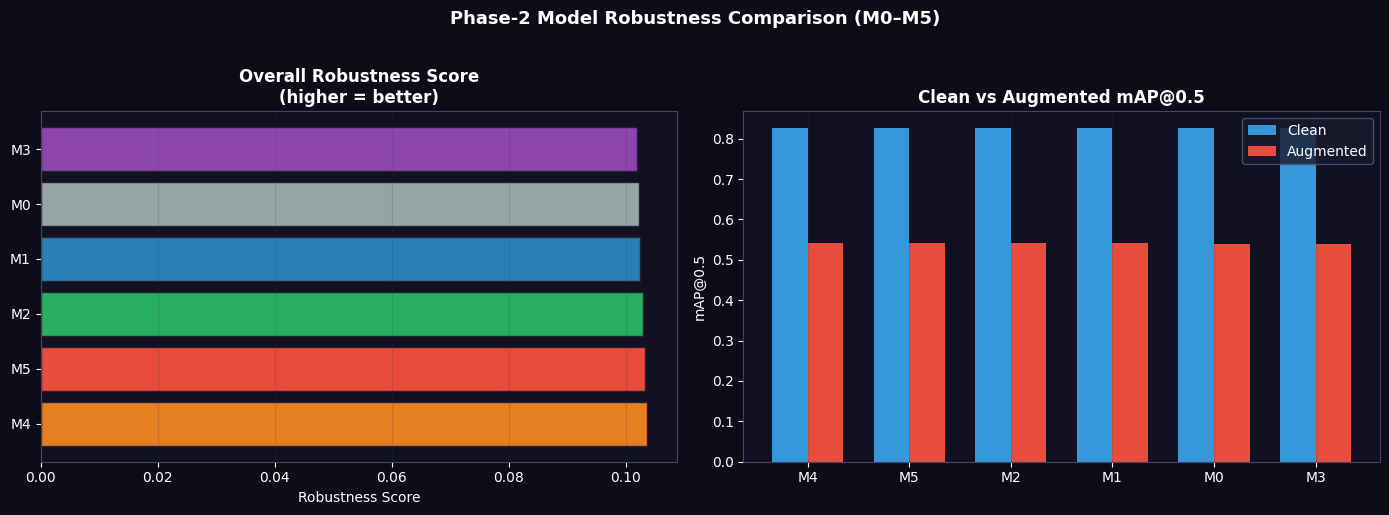

In [6]:
MODEL_COLORS = {
    'M0': '#95a5a6', 'M1': '#2980b9', 'M2': '#27ae60',
    'M3': '#8e44ad', 'M4': '#e67e22', 'M5': '#e74c3c',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0d1a')
for ax in axes:
    ax.set_facecolor('#111122')

model_ids_ranked = ranking['model_id'].tolist()
colors = [MODEL_COLORS.get(m, '#ffffff') for m in model_ids_ranked]

# Left: robustness score
axes[0].barh(model_ids_ranked, ranking['robustness_score'], color=colors, edgecolor='#222233')
axes[0].set_xlabel('Robustness Score', color='white')
axes[0].set_title('Overall Robustness Score\n(higher = better)', color='white', fontweight='bold')

# Right: clean vs augmented
x = np.arange(len(model_ids_ranked))
w = 0.35
axes[1].bar(x - w/2, ranking['clean_map50'],           width=w, label='Clean',     color='#3498db')
axes[1].bar(x + w/2, ranking['mean_map50_augmented'],  width=w, label='Augmented', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_ids_ranked)
axes[1].set_ylabel('mAP@0.5', color='white')
axes[1].set_title('Clean vs Augmented mAP@0.5', color='white', fontweight='bold')
axes[1].legend(facecolor='#1a1a2e', edgecolor='#555577', labelcolor='white')

for ax in axes:
    ax.tick_params(colors='white')
    ax.grid(alpha=0.15, color='#333355', axis='x')
    for sp in ax.spines.values():
        sp.set_color('#444466')

plt.suptitle('Phase-2 Model Robustness Comparison (M0–M5)',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. mAP@0.5 Heatmap — All Models × All Conditions

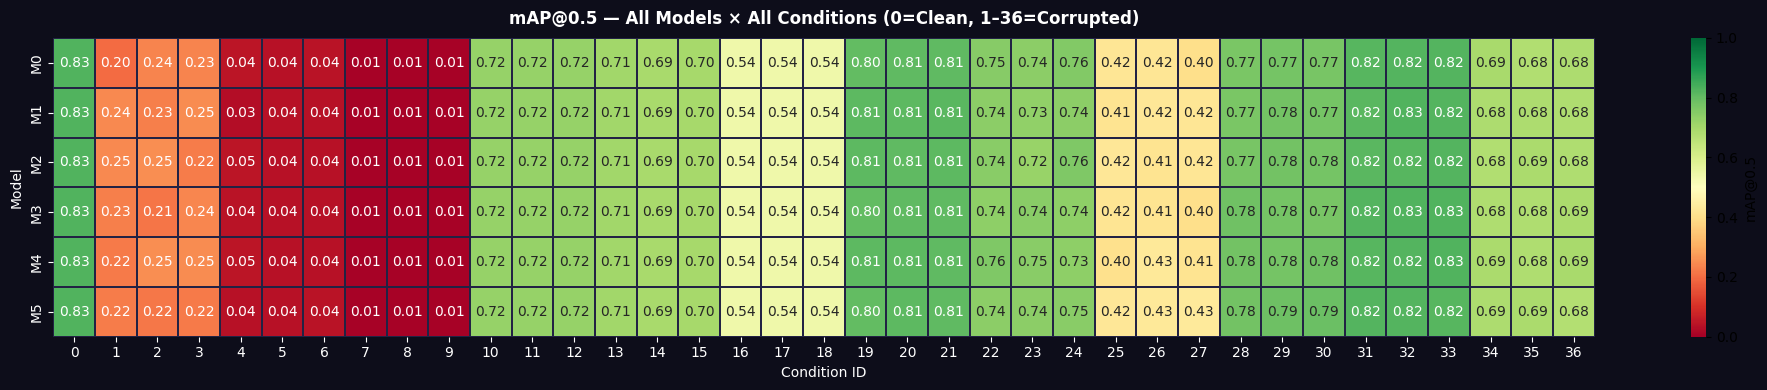

In [7]:
pivot = df.pivot_table(
    index='model_id',
    columns='condition_id',
    values='map50',
    aggfunc='mean',
)

fig, ax = plt.subplots(figsize=(20, 4))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')

sns.heatmap(
    pivot,
    ax=ax,
    vmin=0, vmax=1,
    cmap='RdYlGn',
    annot=True, fmt='.2f',
    linewidths=0.3, linecolor='#222244',
    cbar_kws={'label': 'mAP@0.5'},
)
ax.set_title('mAP@0.5 — All Models × All Conditions (0=Clean, 1–36=Corrupted)',
             color='white', fontsize=12, fontweight='bold', pad=10)
ax.tick_params(colors='white')
ax.set_xlabel('Condition ID', color='white')
ax.set_ylabel('Model', color='white')
plt.tight_layout()
plt.show()

## 6. Degradation by Family — All Models

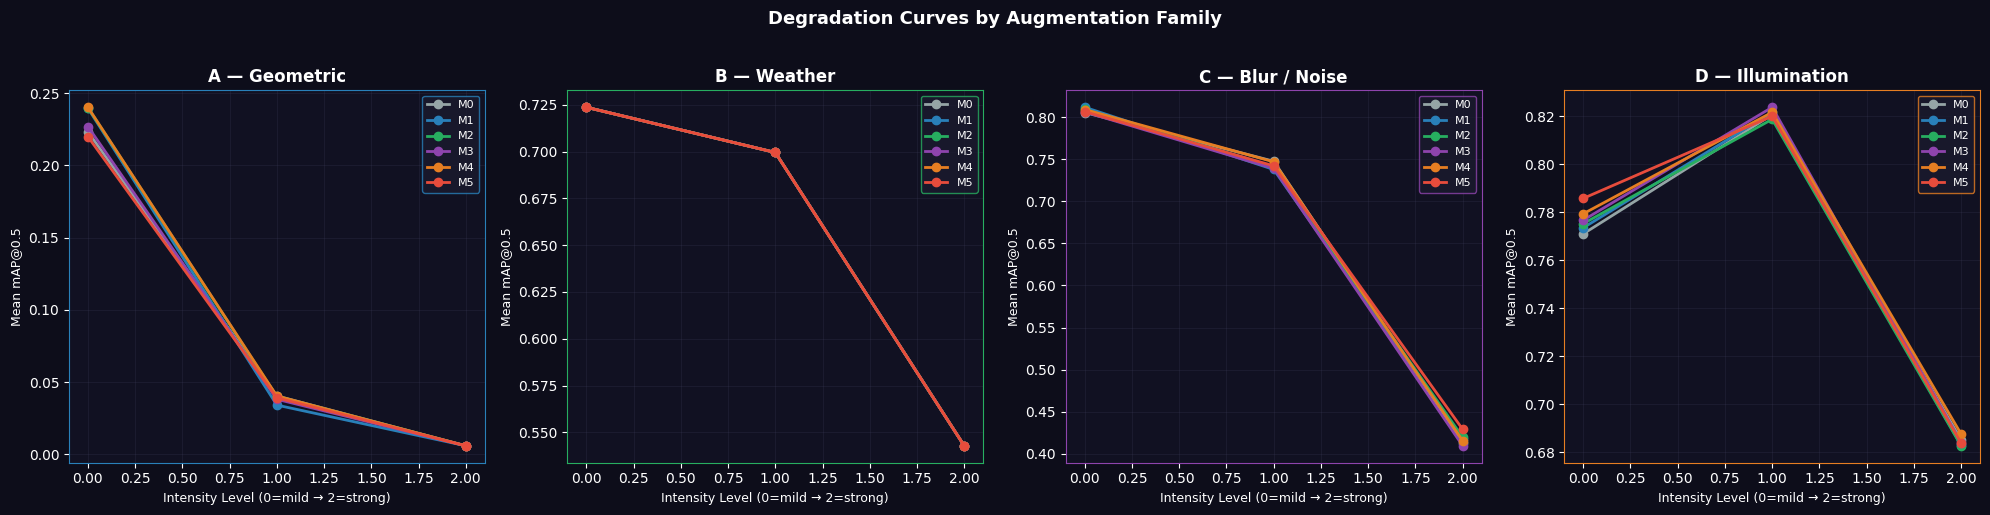

In [8]:
FAMILY_LABELS = {
    'geometric':    'A — Geometric',
    'weather':      'B — Weather',
    'blur_noise':   'C — Blur / Noise',
    'illumination': 'D — Illumination',
}
FAMILY_COLORS = {
    'geometric': '#2980b9', 'weather': '#27ae60',
    'blur_noise': '#8e44ad', 'illumination': '#e67e22',
}

family_keys = [k for k in FAMILY_LABELS if k in df['family'].values]
models_sorted = sorted(df['model_id'].unique())

fig, axes = plt.subplots(1, len(family_keys), figsize=(5 * len(family_keys), 5), sharey=False)
if len(family_keys) == 1:
    axes = [axes]
fig.patch.set_facecolor('#0d0d1a')

for ax, fam_key in zip(axes, family_keys):
    ax.set_facecolor('#111122')
    fdf = df[df['family'] == fam_key]
    for mid in models_sorted:
        mdf   = fdf[fdf['model_id'] == mid]
        means = mdf.groupby('row_idx')['map50'].mean().sort_index()
        ax.plot(means.index, means.values,
                marker='o', linewidth=2,
                color=MODEL_COLORS.get(mid, '#ffffff'),
                label=mid)
    ax.set_title(FAMILY_LABELS[fam_key], color='white', fontweight='bold')
    ax.set_xlabel('Intensity Level (0=mild → 2=strong)', color='white', fontsize=9)
    ax.set_ylabel('Mean mAP@0.5', color='white', fontsize=9)
    ax.tick_params(colors='white')
    ax.grid(alpha=0.2, color='#444466')
    ax.legend(facecolor='#1a1a2e', edgecolor=FAMILY_COLORS[fam_key],
               labelcolor='white', fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(FAMILY_COLORS[fam_key])

plt.suptitle('Degradation Curves by Augmentation Family',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Delta mAP@0.5 — Degradation Relative to Clean Baseline

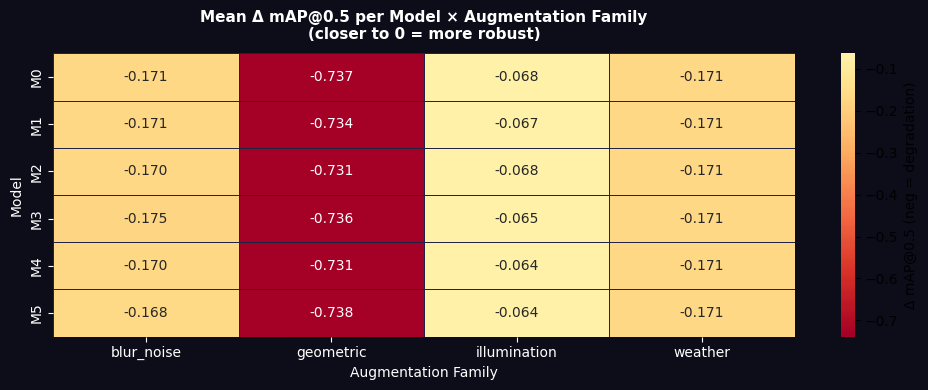


Delta mAP@0.5 table:


family,blur_noise,geometric,illumination,weather
model_id,,,,
M0,-0.1714,-0.7368,-0.0678,-0.1714
M1,-0.1710,-0.7335,-0.0674,-0.1714
M2,-0.1701,-0.7314,-0.0678,-0.1714
M3,-0.1752,-0.7364,-0.0652,-0.1714
M4,-0.1696,-0.7312,-0.0639,-0.1714
M5,-0.1675,-0.7384,-0.0635,-0.1714


In [9]:
aug_df = df[df['condition_id'] > 0].copy()

delta_pivot = aug_df.pivot_table(
    index='model_id',
    columns='family',
    values='delta_map50',
    aggfunc='mean',
).round(4)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')

sns.heatmap(
    delta_pivot,
    ax=ax,
    cmap='RdYlGn',
    annot=True, fmt='.3f',
    center=0,
    linewidths=0.4, linecolor='#222244',
    cbar_kws={'label': 'Δ mAP@0.5 (neg = degradation)'},
)
ax.set_title('Mean Δ mAP@0.5 per Model × Augmentation Family\n(closer to 0 = more robust)',
             color='white', fontsize=11, fontweight='bold', pad=10)
ax.tick_params(colors='white')
ax.set_xlabel('Augmentation Family', color='white')
ax.set_ylabel('Model', color='white')
plt.tight_layout()
plt.show()

print('\nDelta mAP@0.5 table:')
display(delta_pivot)

## 8. Show Pre-generated Plot Images (if --plots was used)

In [10]:
comparison_png = PROJECT_ROOT / 'results' / 'model_comparison.png'
if comparison_png.exists():
    display(IPImage(str(comparison_png)))
else:
    print(f'model_comparison.png not found at {comparison_png}')
    print('Run: python scripts/evaluate.py -m all --plots')

model_comparison.png not found at e:\ScaleVision\results\model_comparison.png
Run: python scripts/evaluate.py -m all --plots


In [11]:
heatmap_dir = PROJECT_ROOT / 'results' / 'heatmaps'
heatmap_pngs = sorted(heatmap_dir.glob('*.png')) if heatmap_dir.exists() else []

if heatmap_pngs:
    print(f'Found {len(heatmap_pngs)} heatmap images in {heatmap_dir}')
    # Show first 6
    for p in heatmap_pngs[:6]:
        print(f'  {p.name}')
        display(IPImage(str(p), width=600))
else:
    print(f'No heatmap images found in {heatmap_dir}')
    print('Run: python scripts/evaluate.py -m all --plots')

No heatmap images found in e:\ScaleVision\results\heatmaps
Run: python scripts/evaluate.py -m all --plots


## 9. Final Ranking Table

In [12]:
print('Final Robustness Ranking (Rank 1 = most robust):')
display(ranking.style
    .background_gradient(subset=['robustness_score'], cmap='RdYlGn')
    .background_gradient(subset=['clean_map50', 'mean_map50_augmented', 'worst_map50'], cmap='YlGn')
    .background_gradient(subset=['mean_delta_map50'], cmap='RdYlGn_r')
    .format({
        'clean_map50':           '{:.4f}',
        'mean_map50_augmented':  '{:.4f}',
        'worst_map50':           '{:.4f}',
        'mean_delta_map50':      '{:.4f}',
        'mean_degradation_slope':'{:.5f}',
        'robustness_score':      '{:.4f}',
    })
)

Final Robustness Ranking (Rank 1 = most robust):


,rank,model_id,clean_map50,mean_map50_augmented,worst_map50,mean_delta_map50,mean_degradation_slope,robustness_score
0,1,M4,0.8267,0.5427,0.0060,-0.2840,-0.11257,0.1036
1,2,M5,0.8267,0.5415,0.0060,-0.2852,-0.10928,0.1033
2,3,M2,0.8267,0.5415,0.0060,-0.2852,-0.11214,0.1029
3,4,M1,0.8267,0.5409,0.0060,-0.2858,-0.11240,0.1025
4,5,M0,0.8267,0.5399,0.0060,-0.2868,-0.10955,0.1023
5,6,M3,0.8267,0.5397,0.0060,-0.2870,-0.11139,0.1019
